#Import Library

In [ ]:
!pip install nltk gensim scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

from gensim.models import Word2Vec

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('omw-1.4')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.3 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving mbgratis (1).csv to mbgratis (1).csv


In [ ]:
df = pd.read_csv("mbgratis (1).csv")

df.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,2036669013678506013,Wed Mar 25 06:01:17 +0000 2026,3,@OniDewono @kompascom Haha pertanyaan on point...,2036684828578336820,NaN,OniDewono,in,NaN,0,1,0,https://x.com/undefined/status/203668482857833...,1720665183188922368,NaN
1,2035892165809996140,Tue Mar 24 14:45:27 +0000 2026,0,@bangherwin Makan Bergizi Gratis giliran pendi...,2036454350814580789,NaN,bangherwin,in,NaN,0,0,0,https://x.com/undefined/status/203645435081458...,1586234677018255360,NaN
2,2036053568499937414,Tue Mar 24 14:19:48 +0000 2026,0,@adepedia Yah begini kalo dikasi pilihan pendi...,2036447894224715820,NaN,adepedia,in,NaN,0,0,0,https://x.com/undefined/status/203644789422471...,2827901161,NaN
3,2036440929775636821,Tue Mar 24 13:56:15 +0000 2026,1,@yush_abubakar Berdasarkan sampling 30+ post &...,2036441969354805397,NaN,yush_abubakar,in,NaN,0,1,1,https://x.com/undefined/status/203644196935480...,1720665183188922368,NaN
4,2036348130191716596,Tue Mar 24 07:43:22 +0000 2026,0,Kesimpulan sementara: Lebih baik Makan Bergizi...,2036348130191716596,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/203634813019171...,385122585,NaN


In [ ]:
data = df.sample(n=min(100, len(df)), random_state=42)
texts = data['full_text'].astype(str)
texts

,full_text
68,Program Makan Bergizi Gratis (MBG) hadir untuk...
22,@yush_abubakar Berdasarkan sampling 30+ post &...
72,Wamendagri Bima Arya Sugiarto mengatakan Presi...
73,@SemestaRak18107 Program Makan Bergizi Gratis ...
0,@OniDewono @kompascom Haha pertanyaan on point...
...,...
60,@yush_abubakar Berdasarkan sampling 30+ post &...
71,Wamendagri Bima Arya Sugiarto mengatakan Presi...
14,Wamendagri Bima Arya Sugiarto mengatakan Presi...
92,@SemestaRak18107 Program Makan Bergizi Gratis ...


In [ ]:
stop_words = set(stopwords.words('indonesian'))
custom_stopwords = {
    'yg','dg','dgn','utk','dr','krn',
    'aja','nih','sih','nya','kalo',
    'ga','gak','nggak','dll',
    'ya','lah','pun','kok', 'on',
}
stop_words = stop_words.union(custom_stopwords)
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return tokens
processed_texts = texts.apply(preprocess_text)
processed_texts.head()

,full_text
68,"[program, makan, bergizi, gratis, mbg, hadir, ..."
22,"[yush_abubakar, berdasarkan, sampling, post, a..."
72,"[wamendagri, bima, arya, sugiarto, presiden, r..."
73,"[semestarak, program, makan, bergizi, gratis, ..."
0,"[onidewono, kompascom, haha, point, banget, al..."


In [ ]:
clean_texts = processed_texts.apply(lambda x: " ".join(x))

clean_texts

,full_text
68,program makan bergizi gratis mbg hadir menduku...
22,yush_abubakar berdasarkan sampling post amp re...
72,wamendagri bima arya sugiarto presiden ri prab...
73,semestarak program makan bergizi gratis benarb...
0,onidewono kompascom haha point banget alasan r...
...,...
60,yush_abubakar berdasarkan sampling post amp re...
71,wamendagri bima arya sugiarto presiden ri prab...
14,wamendagri bima arya sugiarto presiden ri prab...
92,semestarak program makan bergizi gratis benarb...


In [ ]:
tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(clean_texts)

print("Shape TF-IDF:", tfidf_matrix.shape)

Shape TF-IDF: (95, 197)


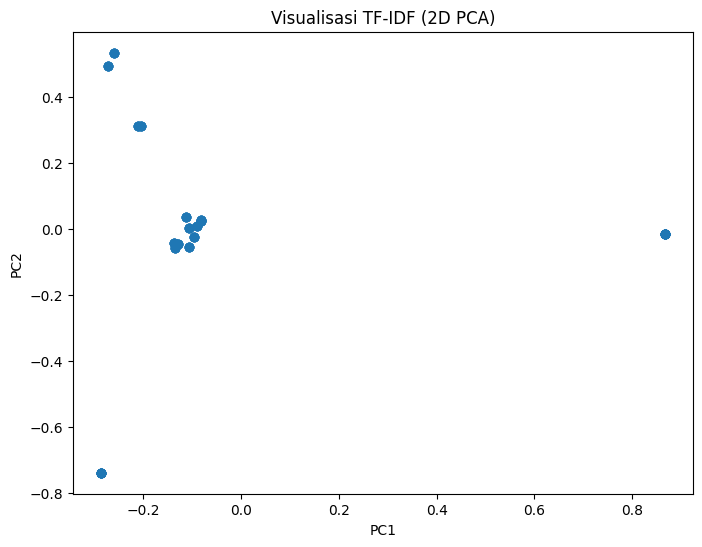

In [ ]:
pca = PCA(n_components=2)

tfidf_2d = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(8,6))

plt.scatter(
    tfidf_2d[:,0],
    tfidf_2d[:,1]
)

plt.title("Visualisasi TF-IDF (2D PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [ ]:
cbow_model = Word2Vec(
    sentences=processed_texts,
    vector_size=100,
    window=5,
    min_count=1,
    sg=0   # CBOW
)

print("CBOW Model Created")

CBOW Model Created


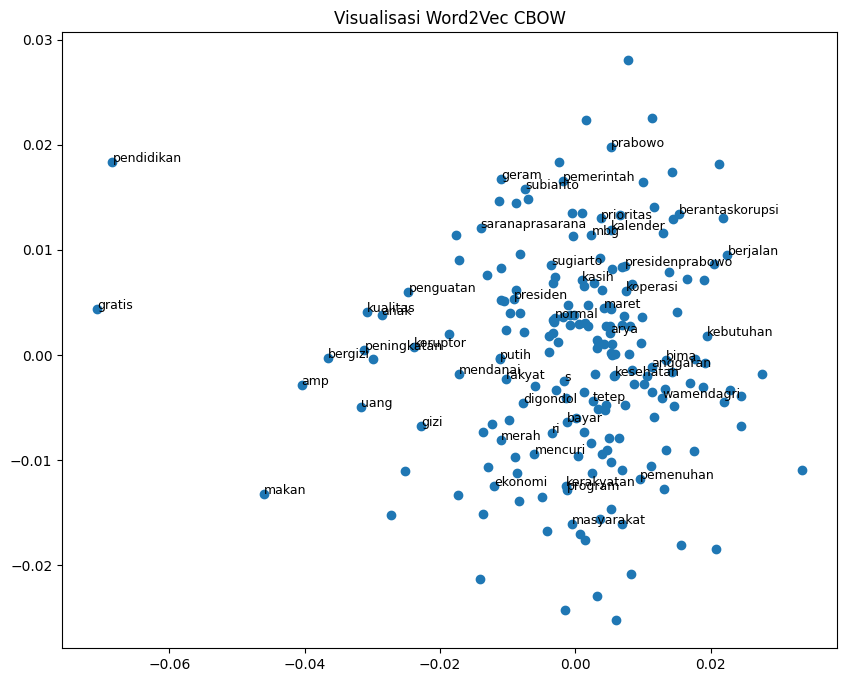

In [ ]:
words = list(cbow_model.wv.index_to_key)
word_vectors = cbow_model.wv[words]
pca = PCA(n_components=2)
cbow_2d = pca.fit_transform(word_vectors)
plt.figure(figsize=(10,8))
plt.scatter(
    cbow_2d[:,0],
    cbow_2d[:,1]
)

# tampilkan beberapa kata
for i, word in enumerate(words[:50]):
    plt.text(
        cbow_2d[i,0],
        cbow_2d[i,1],
        word,
        fontsize=9
    )
plt.title("Visualisasi Word2Vec CBOW")
plt.show()

In [ ]:
skipgram_model = Word2Vec(
    sentences=processed_texts,
    vector_size=100,
    window=5,
    min_count=1,
    sg=1   # Skipgram
)

print("Skipgram Model Created")

Skipgram Model Created


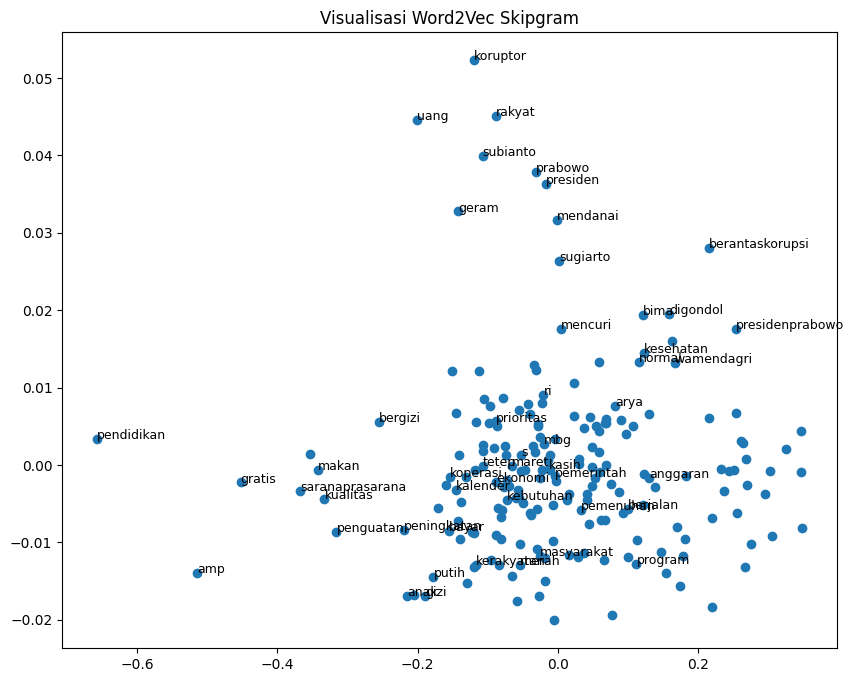

In [ ]:
words = list(skipgram_model.wv.index_to_key)
word_vectors = skipgram_model.wv[words]
pca = PCA(n_components=2)
skip_2d = pca.fit_transform(word_vectors)

plt.figure(figsize=(10,8))
plt.scatter(
    skip_2d[:,0],
    skip_2d[:,1]
)
for i, word in enumerate(words[:50]):
    plt.text(
        skip_2d[i,0],
        skip_2d[i,1],
        word,
        fontsize=9
    )
plt.title("Visualisasi Word2Vec Skipgram")
plt.show()

In [ ]:
cbow_model.wv.most_similar("gratis")

[('pendidikan', 0.7738057971000671),
 ('makan', 0.7093614339828491),
 ('amp', 0.7071387767791748),
 ('gizi', 0.7041353583335876),
 ('peningkatan', 0.6847482323646545),
 ('kualitas', 0.6823364496231079),
 ('anak', 0.6785401105880737),
 ('uang', 0.6736211776733398),
 ('bergizi', 0.6701962351799011),
 ('anakanak', 0.6663426756858826)]

In [ ]:
# Top similar words CBOW
kata_uji = "gratis"

if kata_uji in cbow_model.wv:
    similar_words = cbow_model.wv.most_similar(kata_uji)
    print("Top Similar Words CBOW untuk kata:", kata_uji)
    for word, score in similar_words:
        print(word, ":", score)
else:
    print("Kata tidak ditemukan dalam vocabulary")

Top Similar Words CBOW untuk kata: gratis
pendidikan : 0.7738057971000671
makan : 0.7093614339828491
amp : 0.7071387767791748
gizi : 0.7041353583335876
peningkatan : 0.6847482323646545
kualitas : 0.6823364496231079
anak : 0.6785401105880737
uang : 0.6736211776733398
bergizi : 0.6701962351799011
anakanak : 0.6663426756858826


In [ ]:
# Top similar words Skipgram
kata_uji = "gratis"

if kata_uji in skipgram_model.wv:
    similar_words = skipgram_model.wv.most_similar(kata_uji)
    print("Top Similar Words Skipgram untuk kata:", kata_uji)
    for word, score in similar_words:
        print(word, ":", score)
else:
    print("Kata tidak ditemukan dalam vocabulary")

Top Similar Words Skipgram untuk kata: gratis
pendidikan : 0.9976521730422974
amp : 0.9973353147506714
kualitas : 0.9969848394393921
sekolah : 0.996957540512085
makan : 0.9969410300254822
gizi : 0.9968888759613037
saranaprasarana : 0.9967318177223206
penguatan : 0.9965489506721497
anak : 0.9963241815567017
kerukunan : 0.9963098764419556


In [ ]:
!pip install wordcloud

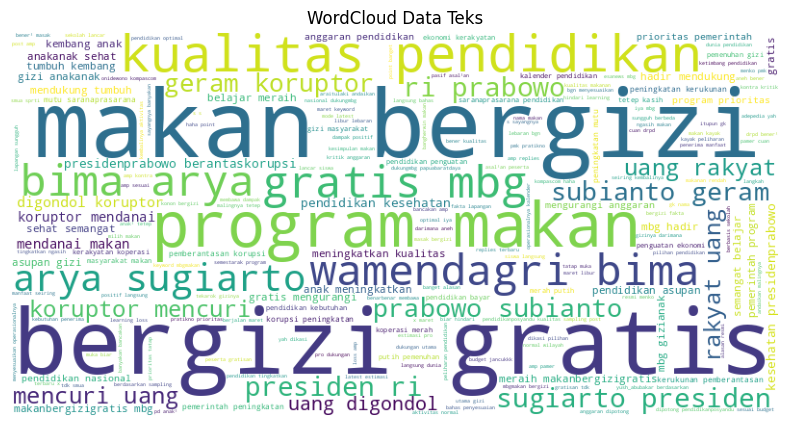

In [ ]:
from wordcloud import WordCloud

all_text = " ".join(clean_texts)
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud Data Teks")
plt.show()

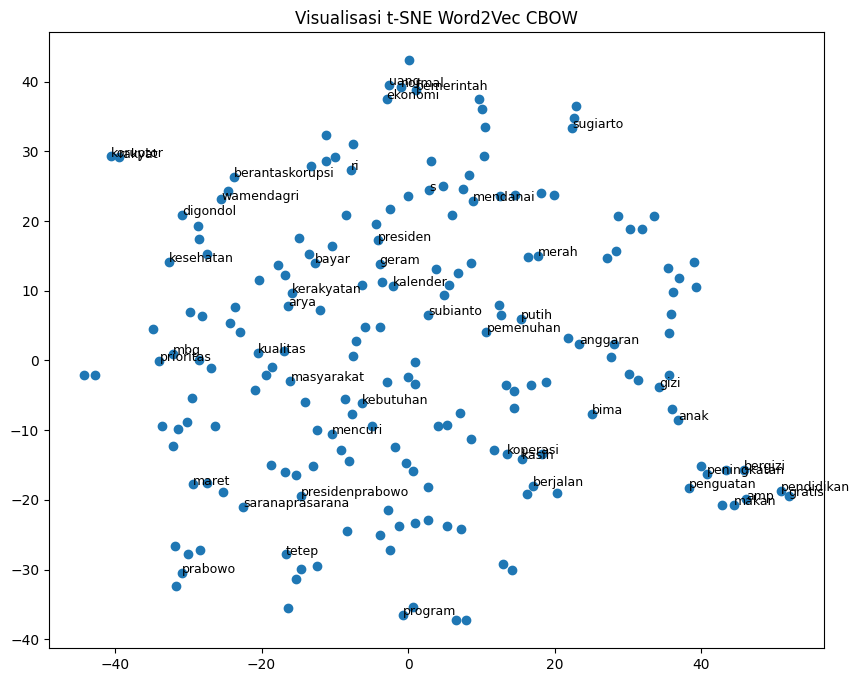

In [ ]:
from sklearn.manifold import TSNE

words = list(cbow_model.wv.index_to_key)
word_vectors = cbow_model.wv[words]
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=5
)
cbow_tsne = tsne.fit_transform(word_vectors)

plt.figure(figsize=(10,8))
plt.scatter(
    cbow_tsne[:,0],
    cbow_tsne[:,1]
)
for i, word in enumerate(words[:50]):
    plt.text(
        cbow_tsne[i,0],
        cbow_tsne[i,1],
        word,
        fontsize=9
    )
plt.title("Visualisasi t-SNE Word2Vec CBOW")
plt.show()

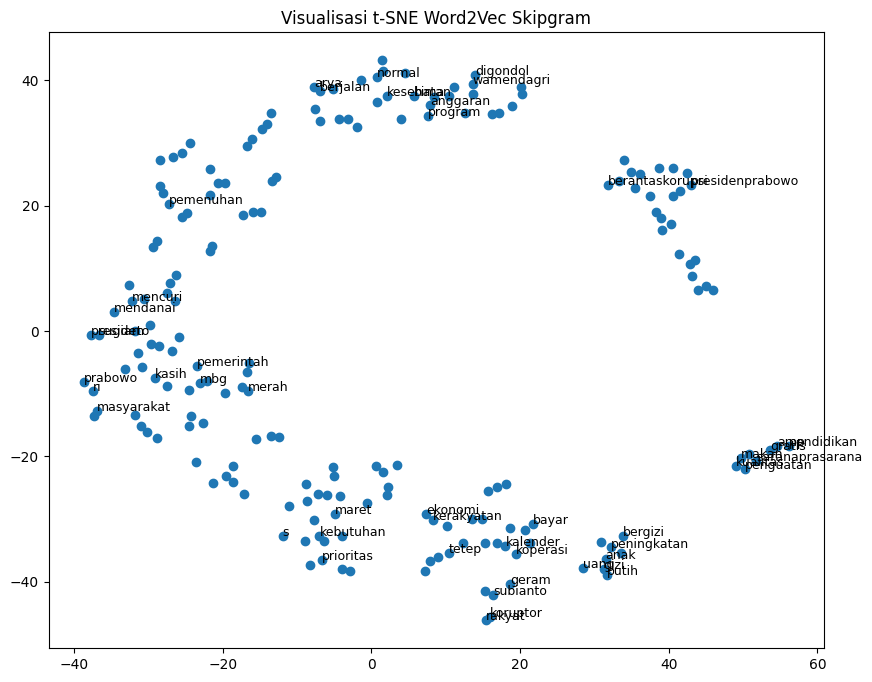

In [ ]:
words = list(skipgram_model.wv.index_to_key)
word_vectors = skipgram_model.wv[words]
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=5
)
skip_tsne = tsne.fit_transform(word_vectors)

plt.figure(figsize=(10,8))
plt.scatter(
    skip_tsne[:,0],
    skip_tsne[:,1]
)
for i, word in enumerate(words[:50]):
    plt.text(
        skip_tsne[i,0],
        skip_tsne[i,1],
        word,
        fontsize=9
    )
plt.title("Visualisasi t-SNE Word2Vec Skipgram")
plt.show()